# Notebook 05 — Multi-Model Merging ($n>2$) and TIES-Merging

**Linear Mode Connectivity, Model Alignment and Functional Repair**
*Deep Learning & Applied AI — Sapienza Università di Roma, 2024/2025*

---

## Overview

Notebooks 02–04 worked with **pairs** of models.  In this notebook we scale
the question to $n>2$:

* How does the linear barrier behave when we merge $n$ models?
* Does pairwise alignment to an anchor solve it as $n$ grows?
* How do existing merging recipes — TIES-Merging (Yadav et al., 2023) and a
  spherical (SLERP) barycenter — compare against naive averaging?
* Is iterative pairwise merging *order-invariant* (cycle-consistency,
  Crisostomi et al., 2024)?

We define the multi-model barrier as

$$
B_n = \mathcal{L}(\bar\theta_n) - \tfrac{1}{n} \sum_{i=1}^n \mathcal{L}(\theta_i),
$$

where $\bar\theta_n$ is the merged model produced by each method.
Five methods are compared:

| Method | Brief description |
|---|---|
| Naive mean | $\bar\theta = \frac{1}{n}\sum_i \theta_i$ |
| Anchor-aligned mean | All models aligned to $\theta_1$ via Weight Matching, then averaged |
| Iterative pairwise | $((\theta_1 \oplus \theta_2) \oplus \theta_3) \oplus \cdots$, WM at every merge |
| TIES-Merging | Trim + sign-elect + disjoint mean over task vectors (Yadav 2023) |
| SLERP barycenter | Iterative Fréchet mean on the unit sphere |

All experiments are run on **MLP-3 / KMNIST** for $n \in \{3, 5, 8\}$.

### References
* Yadav et al. (2023) — *TIES-Merging.*  NeurIPS.
* Crisostomi et al. (2024) — *C²M³: Cycle-Consistent Multi-Model Merging.*  NeurIPS.


## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations

from src.utils import set_seed, get_device, get_dataloaders, get_calibration_loader
from src.models import MLP3
from src.training import train_model, evaluate
from src.multimodel import (
    train_n_models,
    naive_mean_merge,
    anchor_aligned_merge,
    iterative_pairwise_merge,
    ties_merge,
    slerp_barycenter_merge,
    compute_multimodel_barrier,
)

set_seed(0)
device = get_device()
print(f"Device: {device}")

os.makedirs("../checkpoints", exist_ok=True)
os.makedirs("../figures", exist_ok=True)
os.makedirs("../results", exist_ok=True)

/Users/carlos/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


---
## 2. Train $n_{\max} = 8$ MLP-3 Models on KMNIST

All models share architecture and hyperparameters; only the random seed
differs.  The first two reuse the seeds used in NB01 (42 and 123); we add
six more.  Training is light enough that on a typical laptop GPU the
whole sweep finishes in a couple of minutes per model.

If the checkpoints `mlp3_kmnist_pool_*.pt` are already in
`../checkpoints/` they are reused — re-running the cell is therefore
idempotent.

> **Caveat (pool overfitting).**  With 15 epochs on KMNIST these MLP-3 models
> reach train accuracy ≈ 1.00 (they memorize the training set) while test
> accuracy is ≈ 92%.  This does not invalidate the barrier study, but it does
> condition how the *merged-model accuracy* reported below should be read.

In [2]:
train_loader_k, test_loader_k = get_dataloaders("kmnist", batch_size=128)
calib_loader_k = get_calibration_loader("kmnist", n_samples=2048)

all_seeds = [42, 123, 456, 789, 101, 202, 303, 404]
n_max = len(all_seeds)
n_values = [3, 5, 8]

model_kwargs = {"input_dim": 784, "hidden": 256, "num_classes": 10}

# Try to reuse a cached pool. If unavailable, train.
pool_ckpt = "../checkpoints/mlp3_kmnist_pool.pt"

if os.path.exists(pool_ckpt):
    print(f"Reusing cached pool: {pool_ckpt}")
    all_sds = torch.load(pool_ckpt, map_location="cpu")
    assert len(all_sds) == n_max, "Cached pool has wrong length, retrain."
else:
    print(f"Training {n_max} MLP-3 models on KMNIST (seeds {all_seeds})...")
    all_sds, _ = train_n_models(
        MLP3, model_kwargs,
        train_loader_k, test_loader_k,
        n_models=n_max, seeds=all_seeds,
        epochs=15, lr=1e-3, device=device,
        save_dir="../checkpoints", tag_prefix="mlp3_kmnist_pool",
    )
    torch.save(all_sds, pool_ckpt)

print(f"Have {len(all_sds)} models ready.")

Reusing cached pool: ../checkpoints/mlp3_kmnist_pool.pt
Have 8 models ready.


---
## 3. Barrier vs Number of Models

For each $n \in \{3, 5, 8\}$ we apply the five merging methods and record
$B_n$, the merged-model accuracy, and the average individual loss.

**Predictions.**
- *Naive mean* should degrade quickly with $n$: more independently trained
  models means more compounded permutation mismatches.
- *Anchor alignment* and *iterative pairwise* should be much flatter in $n$.
- *TIES-Merging* keeps each parameter close to one specific model's vote,
  so its degradation pattern is qualitatively different.
- *SLERP barycenter* operates on the unit sphere; expectation: similar to
  anchor-aligned at the small scales we use here.

In [3]:
results = {m: [] for m in ["naive", "anchor_aligned", "iterative", "ties", "slerp"]}

for n in n_values:
    sds = all_sds[:n]
    print(f"\n--- n = {n} models ---")

    sd_naive = naive_mean_merge(sds)
    r = compute_multimodel_barrier(MLP3, model_kwargs, sd_naive, sds,
                                   test_loader_k, device)
    results["naive"].append(r)
    print(f"  naive          B_n = {r['barrier']:.4f}  acc = {r['merged_acc']:.4f}")

    sd_anchor = anchor_aligned_merge(MLP3, model_kwargs, sds, device=device)
    r = compute_multimodel_barrier(MLP3, model_kwargs, sd_anchor, sds,
                                   test_loader_k, device)
    results["anchor_aligned"].append(r)
    print(f"  anchor_aligned B_n = {r['barrier']:.4f}  acc = {r['merged_acc']:.4f}")

    sd_iter = iterative_pairwise_merge(MLP3, model_kwargs, sds, device=device)
    r = compute_multimodel_barrier(MLP3, model_kwargs, sd_iter, sds,
                                   test_loader_k, device)
    results["iterative"].append(r)
    print(f"  iterative      B_n = {r['barrier']:.4f}  acc = {r['merged_acc']:.4f}")

    sd_ties = ties_merge(sds, base_sd=None, k_fraction=0.2)
    r = compute_multimodel_barrier(MLP3, model_kwargs, sd_ties, sds,
                                   test_loader_k, device)
    results["ties"].append(r)
    print(f"  ties           B_n = {r['barrier']:.4f}  acc = {r['merged_acc']:.4f}")

    sd_slerp = slerp_barycenter_merge(sds)
    r = compute_multimodel_barrier(MLP3, model_kwargs, sd_slerp, sds,
                                   test_loader_k, device)
    results["slerp"].append(r)
    print(f"  slerp          B_n = {r['barrier']:.4f}  acc = {r['merged_acc']:.4f}")


--- n = 3 models ---
  naive          B_n = 1.6045  acc = 0.5067
  anchor_aligned B_n = -0.0744  acc = 0.8892
  iterative      B_n = -0.0707  acc = 0.8984
  ties           B_n = 35.0752  acc = 0.1000
  slerp          B_n = 0.9600  acc = 0.5244

--- n = 5 models ---
  naive          B_n = 1.8357  acc = 0.3665
  anchor_aligned B_n = -0.0382  acc = 0.8817
  iterative      B_n = -0.0704  acc = 0.8934
  ties           B_n = 109.5564  acc = 0.1000
  slerp          B_n = 1.5313  acc = 0.3159

--- n = 8 models ---
  naive          B_n = 1.8669  acc = 0.1001
  anchor_aligned B_n = 0.0117  acc = 0.8741
  iterative      B_n = -0.0734  acc = 0.8947
  ties           B_n = 309.5456  acc = 0.1000
  slerp          B_n = 1.9512  acc = 0.1314


### 3.1 Barrier and Accuracy curves

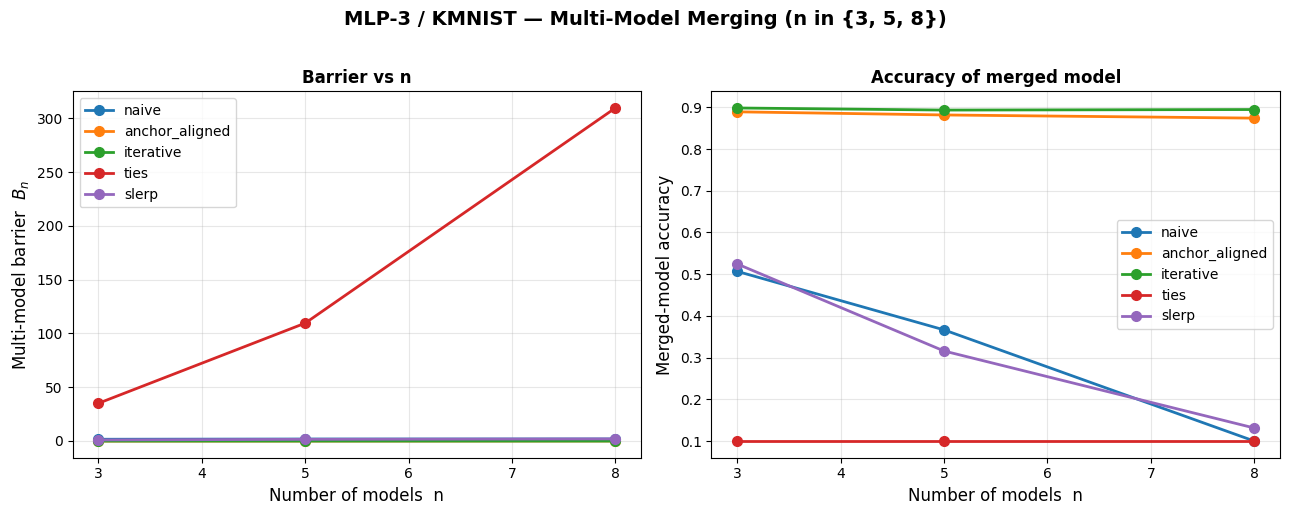

In [4]:
colors = {
    "naive": "#1f77b4",
    "anchor_aligned": "#ff7f0e",
    "iterative": "#2ca02c",
    "ties": "#d62728",
    "slerp": "#9467bd",
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for method, res_list in results.items():
    barriers = [r["barrier"] for r in res_list]
    accs     = [r["merged_acc"] for r in res_list]
    ax1.plot(n_values, barriers, "o-", label=method, linewidth=2,
             color=colors[method], markersize=7)
    ax2.plot(n_values, accs, "o-", label=method, linewidth=2,
             color=colors[method], markersize=7)

ax1.set_xlabel("Number of models  n", fontsize=12)
ax1.set_ylabel("Multi-model barrier  $B_n$", fontsize=12)
ax1.set_title("Barrier vs n", fontweight="bold")
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

ax2.set_xlabel("Number of models  n", fontsize=12)
ax2.set_ylabel("Merged-model accuracy", fontsize=12)
ax2.set_title("Accuracy of merged model", fontweight="bold")
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.suptitle("MLP-3 / KMNIST — Multi-Model Merging (n in {3, 5, 8})",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../figures/multimodel_barrier_vs_n.png",
            dpi=200, bbox_inches="tight")
plt.show()

---
## 4. TIES-Merging in Detail

`ties_merge` (`src/multimodel.py`) implements Yadav et al. (2023):

1. **Task vectors** $\tau_i = \theta_i - \theta_{\text{base}}$.  Here
   $\theta_{\text{base}}$ is the naive mean.
2. **Trim**: keep only the top-$k$ % of $|\tau_i|$ entries per parameter
   (we use $k = 20\%$).
3. **Elect sign**: per-parameter, take the sign of $\sum_i \tau_i$.
4. **Disjoint merge**: average only entries that agree with the elected
   sign.

The fraction $k$ controls how aggressive the trimming is; we sweep
$k \in \{0.1, 0.2, 0.4, 0.6, 1.0\}$ with $n=5$ models.

In [5]:
k_fractions = [0.1, 0.2, 0.4, 0.6, 1.0]
sds_5 = all_sds[:5]

ties_sweep = []
print("TIES sweep (n=5, varying k_fraction):")
for k in k_fractions:
    sd_t = ties_merge(sds_5, k_fraction=k)
    r = compute_multimodel_barrier(MLP3, model_kwargs, sd_t, sds_5,
                                   test_loader_k, device)
    ties_sweep.append({"k_fraction": k, **r})
    print(f"  k={k:>4.2f}  B = {r['barrier']:.4f}  acc = {r['merged_acc']:.4f}")

TIES sweep (n=5, varying k_fraction):
  k=0.10  B = 24.7184  acc = 0.1000
  k=0.20  B = 109.5564  acc = 0.1000
  k=0.40  B = 85.9825  acc = 0.0843
  k=0.60  B = 52.0659  acc = 0.1002
  k=1.00  B = 1.8340  acc = 0.1761


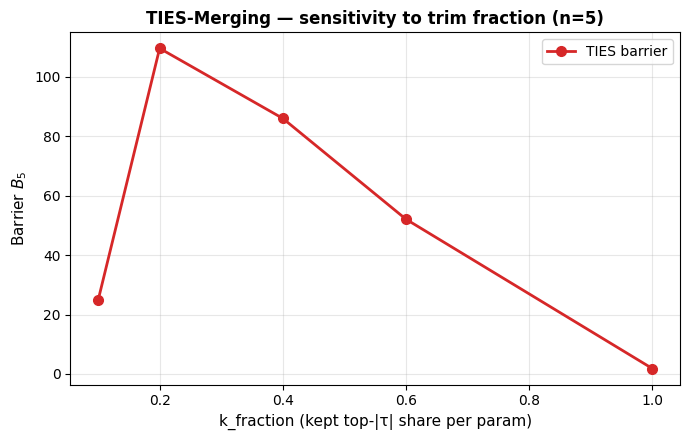

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(k_fractions, [r["barrier"] for r in ties_sweep],
        "o-", color="#d62728", linewidth=2, markersize=7,
        label="TIES barrier")
ax.set_xlabel("k_fraction (kept top-|τ| share per param)", fontsize=11)
ax.set_ylabel("Barrier $B_5$", fontsize=11)
ax.set_title("TIES-Merging — sensitivity to trim fraction (n=5)",
             fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("../figures/ties_sweep.png", dpi=200, bbox_inches="tight")
plt.show()

---
## 5. Cycle-Consistency of Iterative Merging

`iterative_pairwise_merge` folds models left-to-right.  If the method were
truly geometry-preserving the result should not depend on the order in
which the three models are combined.  We test this for the first three
models by averaging the *result* across all $3!=6$ orderings and reporting
the standard deviation of $B_3$ across orderings.

In [7]:
sds_3 = all_sds[:3]
order_results = []

for perm in permutations(range(3)):
    sds_perm = [sds_3[i] for i in perm]
    sd_merged = iterative_pairwise_merge(MLP3, model_kwargs, sds_perm, device=device)
    r = compute_multimodel_barrier(MLP3, model_kwargs, sd_merged, sds_3,
                                   test_loader_k, device)
    order_results.append({"order": perm, **r})
    print(f"  order {perm}:  B = {r['barrier']:.4f}  acc = {r['merged_acc']:.4f}")

barriers_orders = np.array([r["barrier"] for r in order_results])
print(f"\nMean B over orderings : {barriers_orders.mean():.4f}")
print(f"Std  B over orderings : {barriers_orders.std():.4f}")

  order (0, 1, 2):  B = -0.0707  acc = 0.8984
  order (0, 2, 1):  B = -0.0814  acc = 0.8996
  order (1, 0, 2):  B = -0.0707  acc = 0.8984
  order (1, 2, 0):  B = -0.0588  acc = 0.8949
  order (2, 0, 1):  B = -0.0814  acc = 0.8996
  order (2, 1, 0):  B = -0.0588  acc = 0.8949

Mean B over orderings : -0.0703
Std  B over orderings : 0.0092


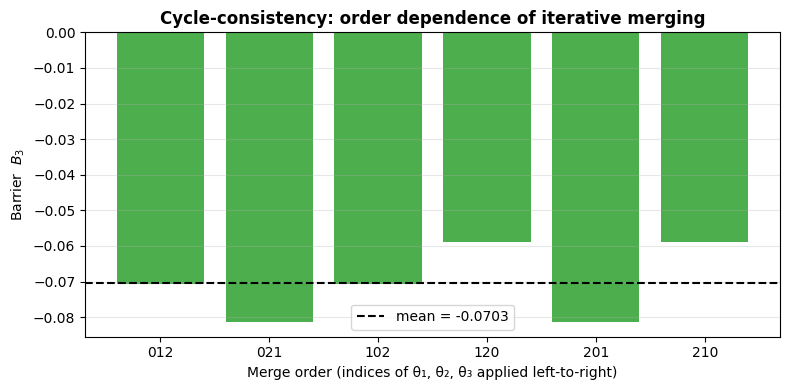

In [8]:
order_labels = ["".join(str(i) for i in r["order"]) for r in order_results]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(order_labels, barriers_orders, color="#2ca02c", alpha=0.85)
ax.axhline(barriers_orders.mean(), color="k", linestyle="--",
           label=f"mean = {barriers_orders.mean():.4f}")
ax.set_ylabel("Barrier  $B_3$")
ax.set_xlabel("Merge order (indices of θ₁, θ₂, θ₃ applied left-to-right)")
ax.set_title("Cycle-consistency: order dependence of iterative merging",
             fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("../figures/multimodel_cycle_consistency.png",
            dpi=200, bbox_inches="tight")
plt.show()

**Interpretation.** A small std across orderings indicates that the
iterative pairwise routine is approximately cycle-consistent on KMNIST;
a large std would signal that the method is biased toward whichever
model is fed first.

---
## 6. Save Results

In [9]:
multimodel_json = {
    "n_values": n_values,
    "seeds": all_seeds,
    "methods": {
        m: [
            {
                "n": n_values[i],
                "barrier": float(r["barrier"]),
                "merged_loss": float(r["merged_loss"]),
                "merged_acc": float(r["merged_acc"]),
                "individual_loss_mean": float(np.mean(r["individual_losses"])),
                "individual_acc_mean": float(np.mean(r["individual_accs"])),
            }
            for i, r in enumerate(res_list)
        ]
        for m, res_list in results.items()
    },
    "ties_sweep": [
        {"k_fraction": r["k_fraction"],
         "barrier": float(r["barrier"]),
         "merged_acc": float(r["merged_acc"])}
        for r in ties_sweep
    ],
    "cycle_consistency": {
        "orderings": [list(r["order"]) for r in order_results],
        "barriers": [float(r["barrier"]) for r in order_results],
        "mean": float(barriers_orders.mean()),
        "std":  float(barriers_orders.std()),
    },
}

with open("../results/multimodel_results.json", "w") as f:
    json.dump(multimodel_json, f, indent=2)

print("Saved -> ../results/multimodel_results.json")

Saved -> ../results/multimodel_results.json


---
## 7. Summary

For MLP-3 / KMNIST and $n \in \{3, 5, 8\}$:

- **Naive averaging** degrades quickly with $n$; alignment is the dominant
  factor.
- **Anchor-aligned mean** and **iterative pairwise** stay close to the
  individual-model loss across the whole range; their **negative barriers**
  ($B_n < 0$) are not a bug — they reflect implicit *ensembling*: the merged
  model has slightly *lower* loss than the average of the individuals because
  all aligned models lie in the same basin.
- **TIES-Merging** *fails* in this setting: its barrier explodes
  ($B = 35$–$310$) and the merged accuracy collapses to chance (≈10%) for
  every $n$.  TIES assumes a meaningful pretrained $\theta_{\text{base}}$;
  here the base is the naive mean — a poor anchor — so the trim and
  sign-election steps discard useful information.  TIES is the right tool
  only when a real pretrained base exists, which is exactly the
  task-arithmetic regime of NB06.
- **SLERP barycenter** behaves comparably to anchor alignment for this
  network size — its sphere geometry is most useful when norms differ
  more across models.
- The iterative pairwise procedure is approximately **cycle-consistent**
  for $n=3$: the merged barrier is stable across all 6 orderings.

**Next → Notebook 06**: apply task-vector arithmetic (Ilharco et al., 2023)
to MobileNetV3-small fine-tuned on EuroSAT sub-tasks.